In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as mtick
import seaborn as sns
import re
import ipywidgets as widgets
import brainJ_output_analysis_v1 as bj
import warnings
from glob import glob
from functools import reduce
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
data_dir = '/Users/Documents/...'

animals = [
    'MitoPark_8wks_22341_ctrl', 'MitoPark_8wks_22340_test',
    'MitoPark_16wks_21425_ctrl', 'MitoPark_16wks_21426_test',
    'MitoPark_24wks_22842_ctrl', 'MitoPark_24wks_22841_test',
]

dir_type = 'BrainJ_output_proj_'
atlas_type = 'ABA_CCF_updated'

save_dir = os.path.join(data_dir, f'{dir_type}{atlas_type}', 'output')
os.makedirs(save_dir, exist_ok=True)

Atlas_Regions = pd.read_csv(
    os.path.join(data_dir, atlas_type, f'Atlas_Regions_{atlas_type}.csv')
)
ABA_fiber_tract = pd.read_csv(
    os.path.join(data_dir, atlas_type, f'ABA_fiber_tracts_VS_grv_{atlas_type}.csv')
)

Atlas_Regions = Atlas_Regions[
    Atlas_Regions['parent_ID'].isin([485, 493]) &
    ~Atlas_Regions['output_id'].isin([672, 998, 754])
]

inj_site = 'SNc'
channel = 'C3_'
RL = ['Right', 'Left']
RL_short = ['R', 'L']
projection = ['Ipsilateral', 'Contralateral']

density = 'Projection_Density'
density_RL = [f'{density}_Right', f'{density}_Left']

average_method = 'median'
proj_threshold = 2.0
ylim = 12

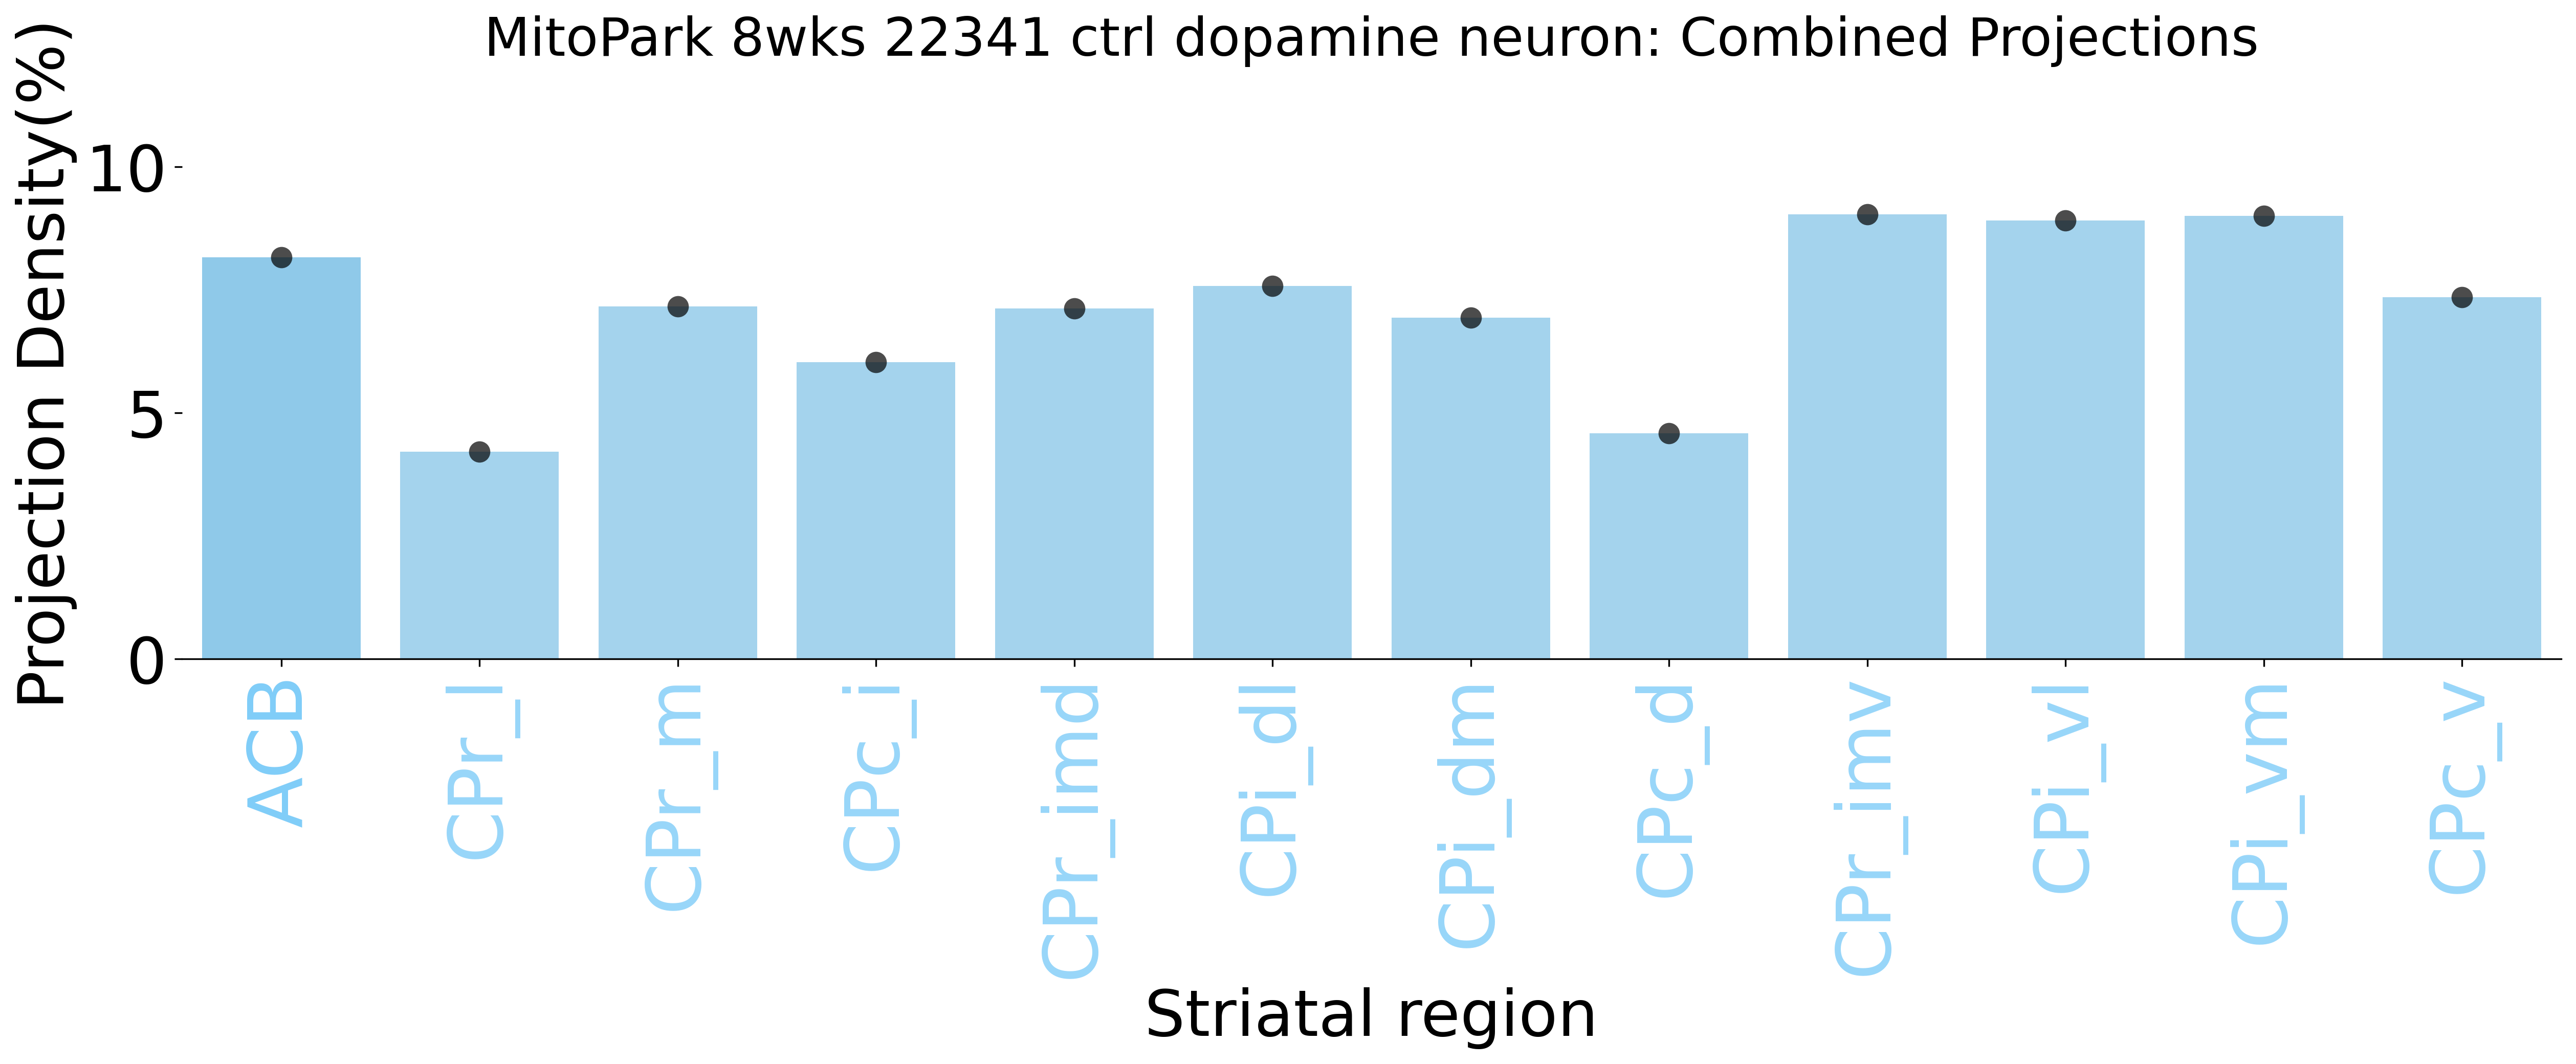

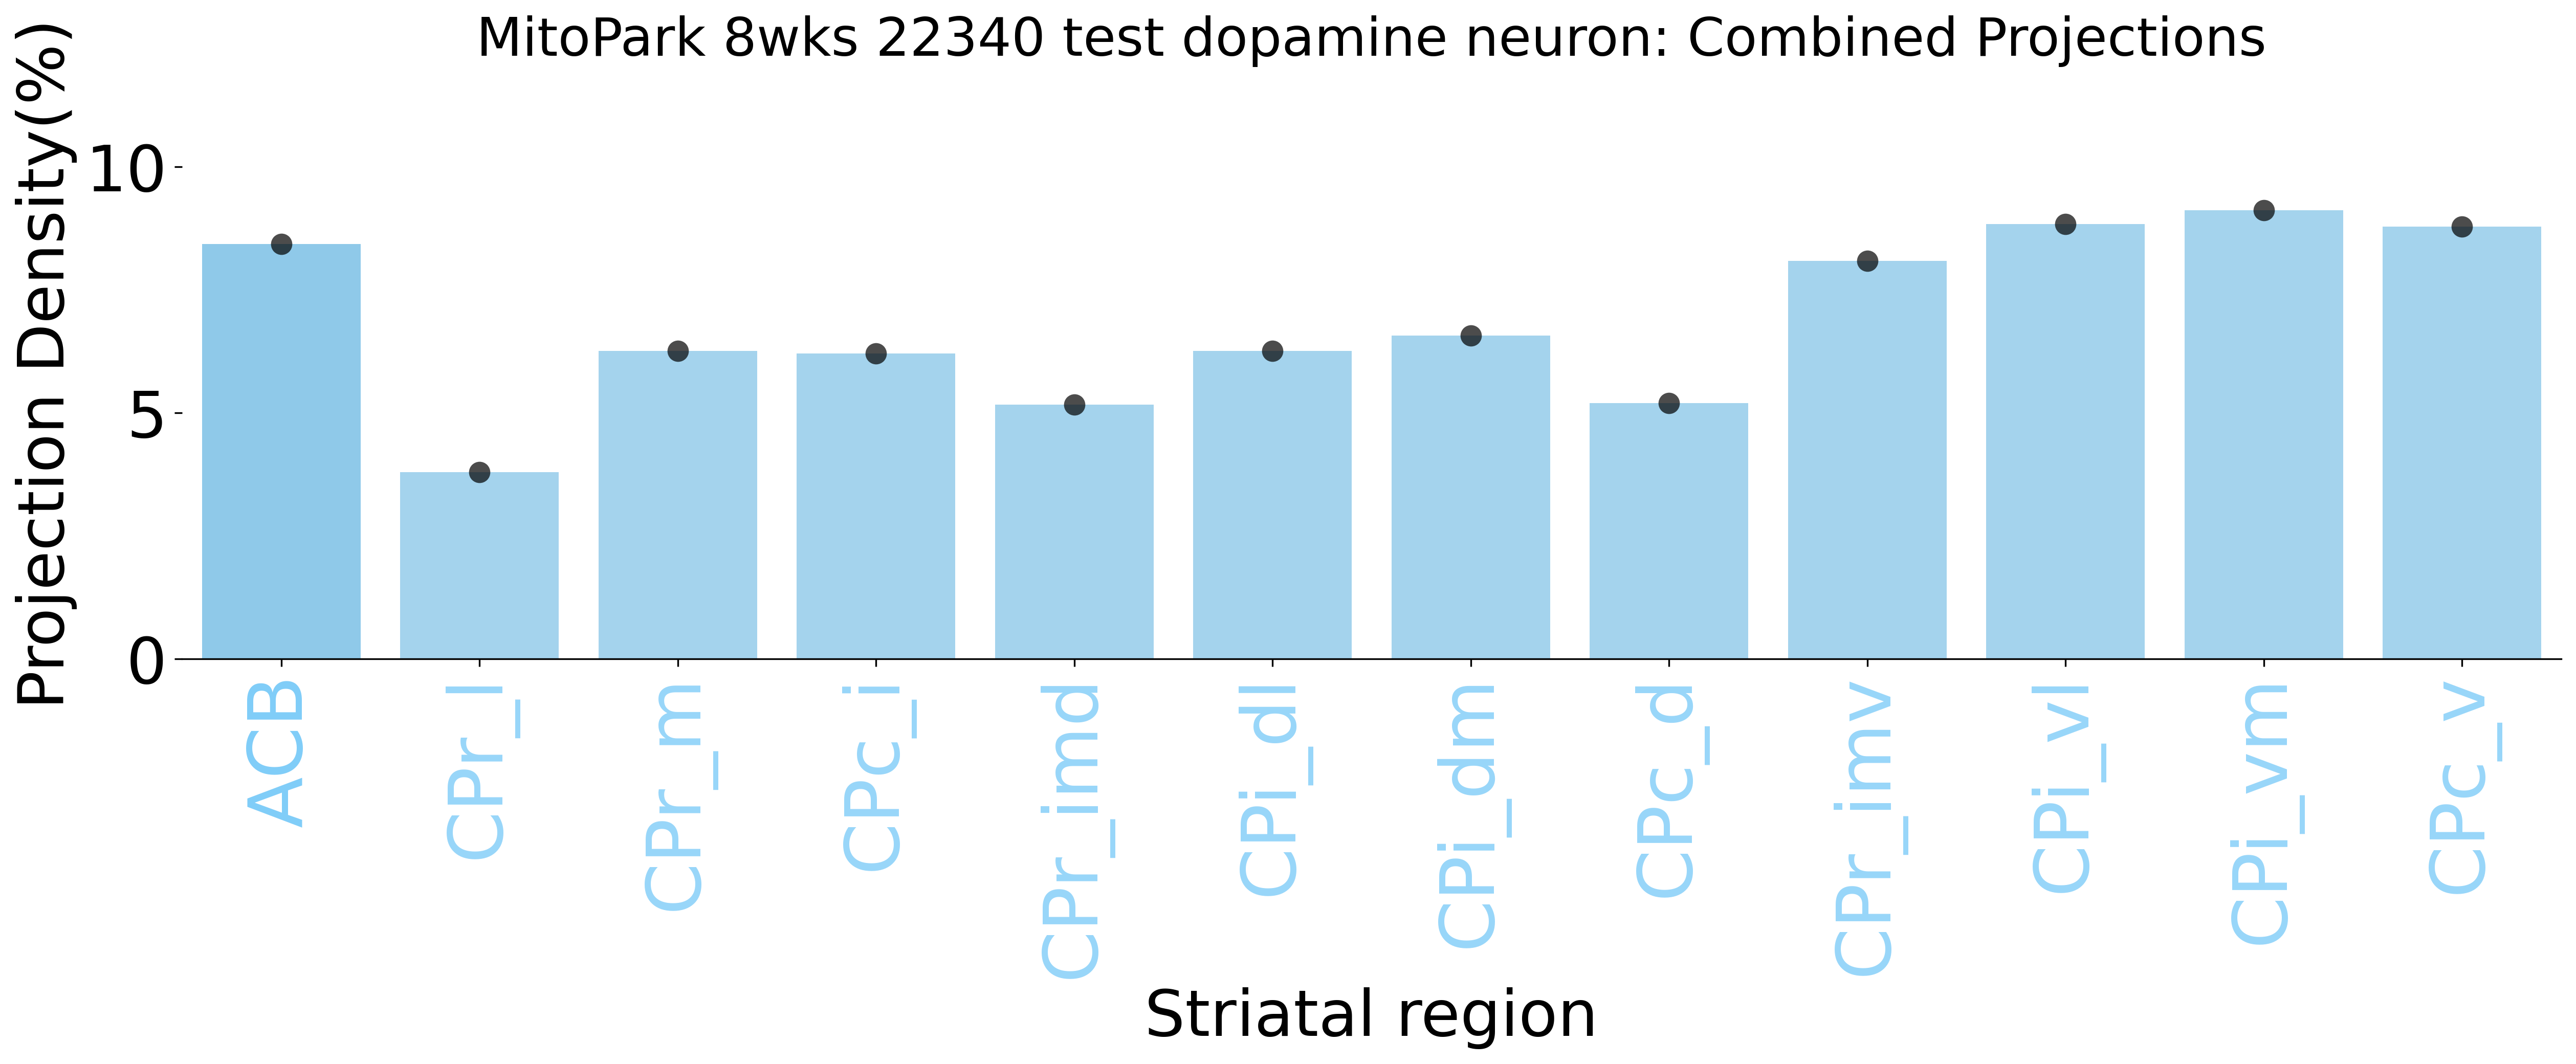

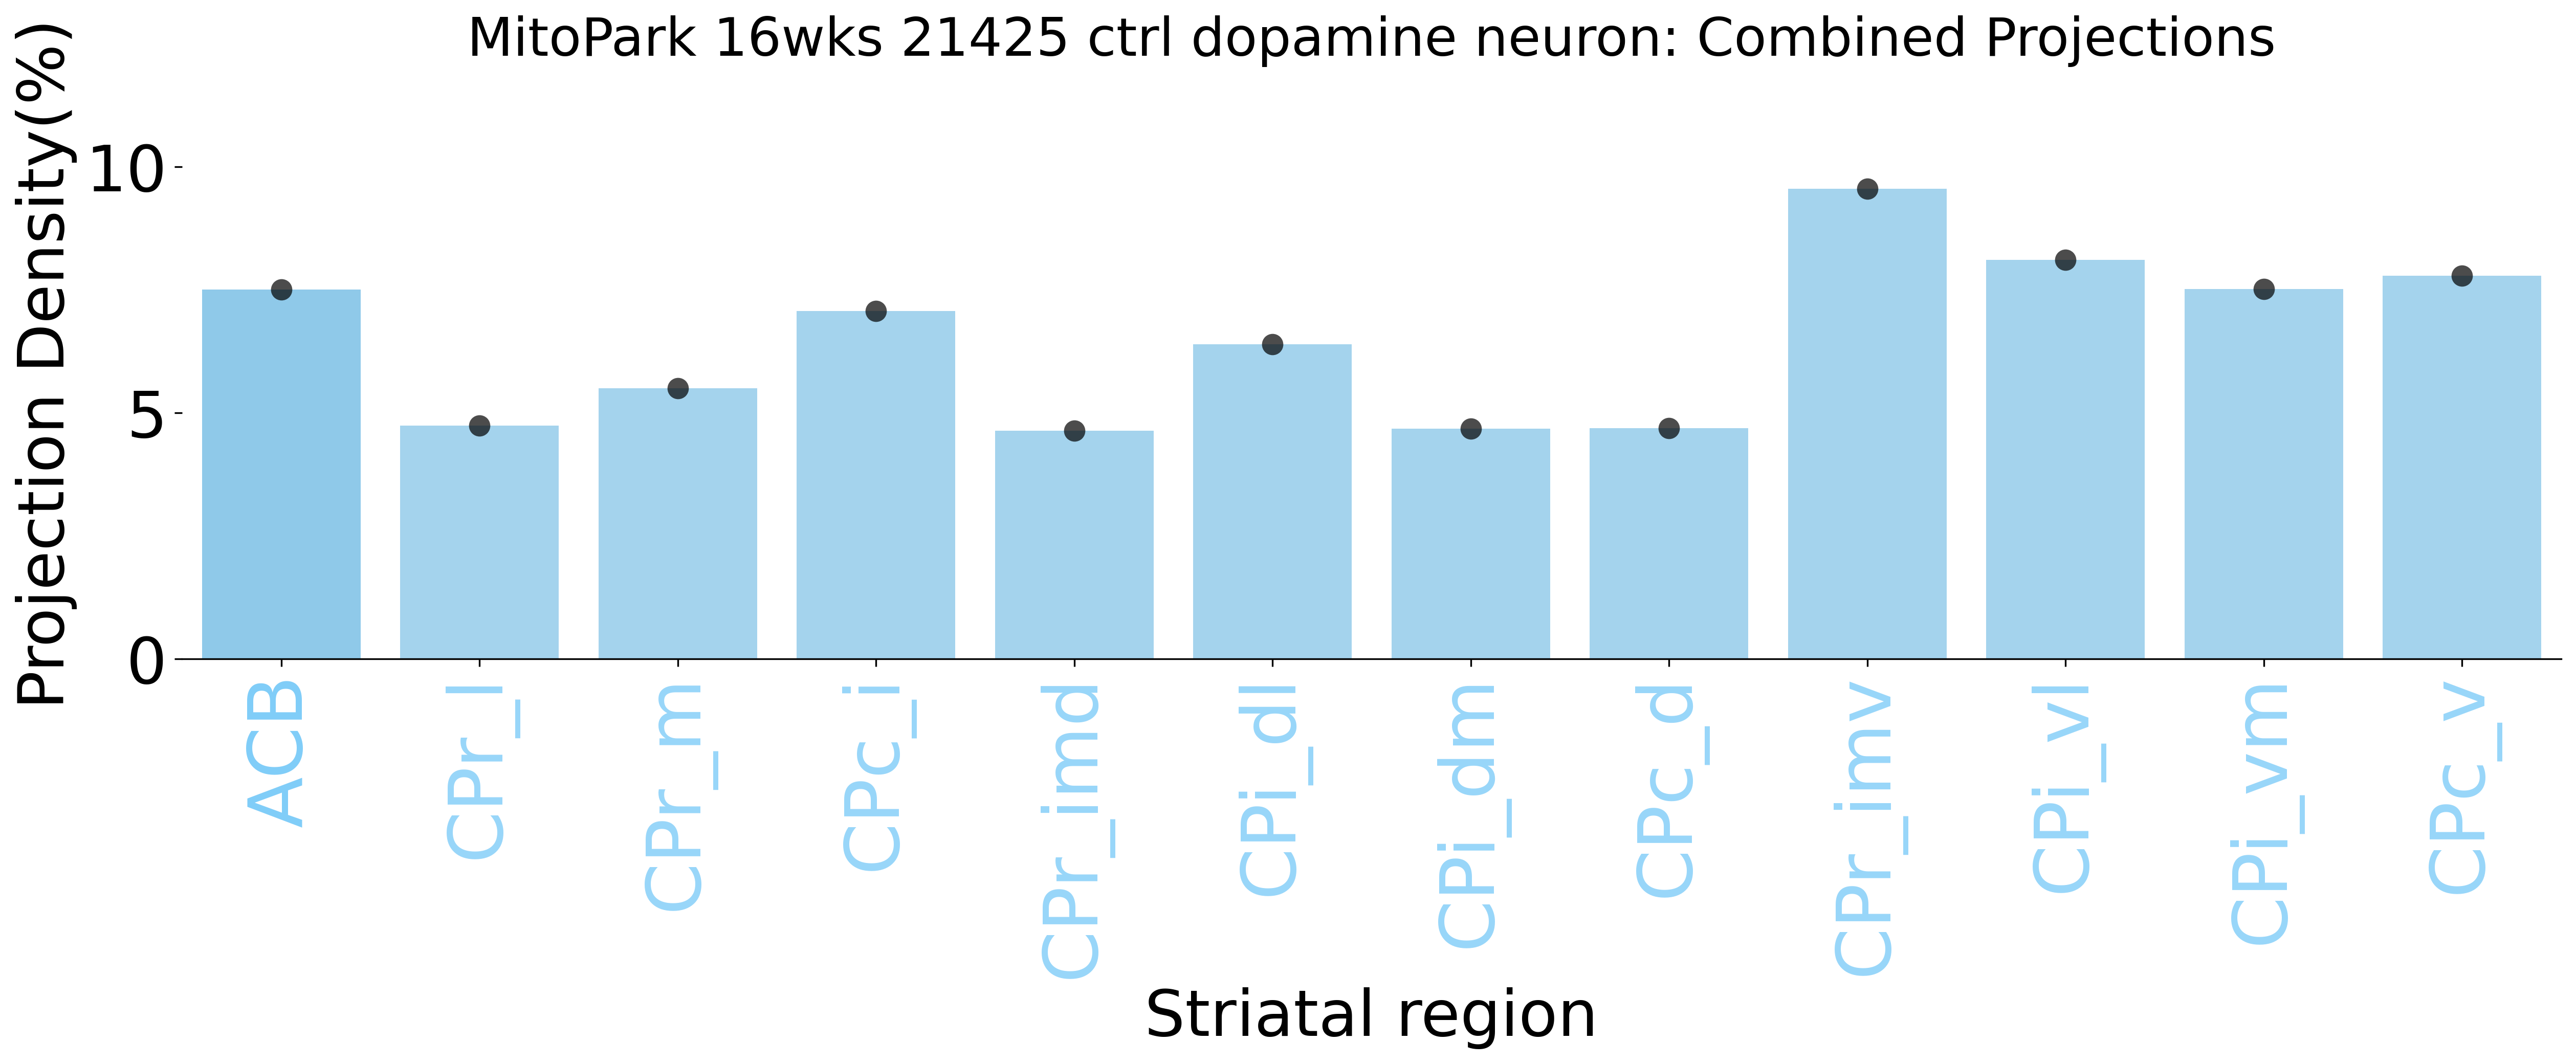

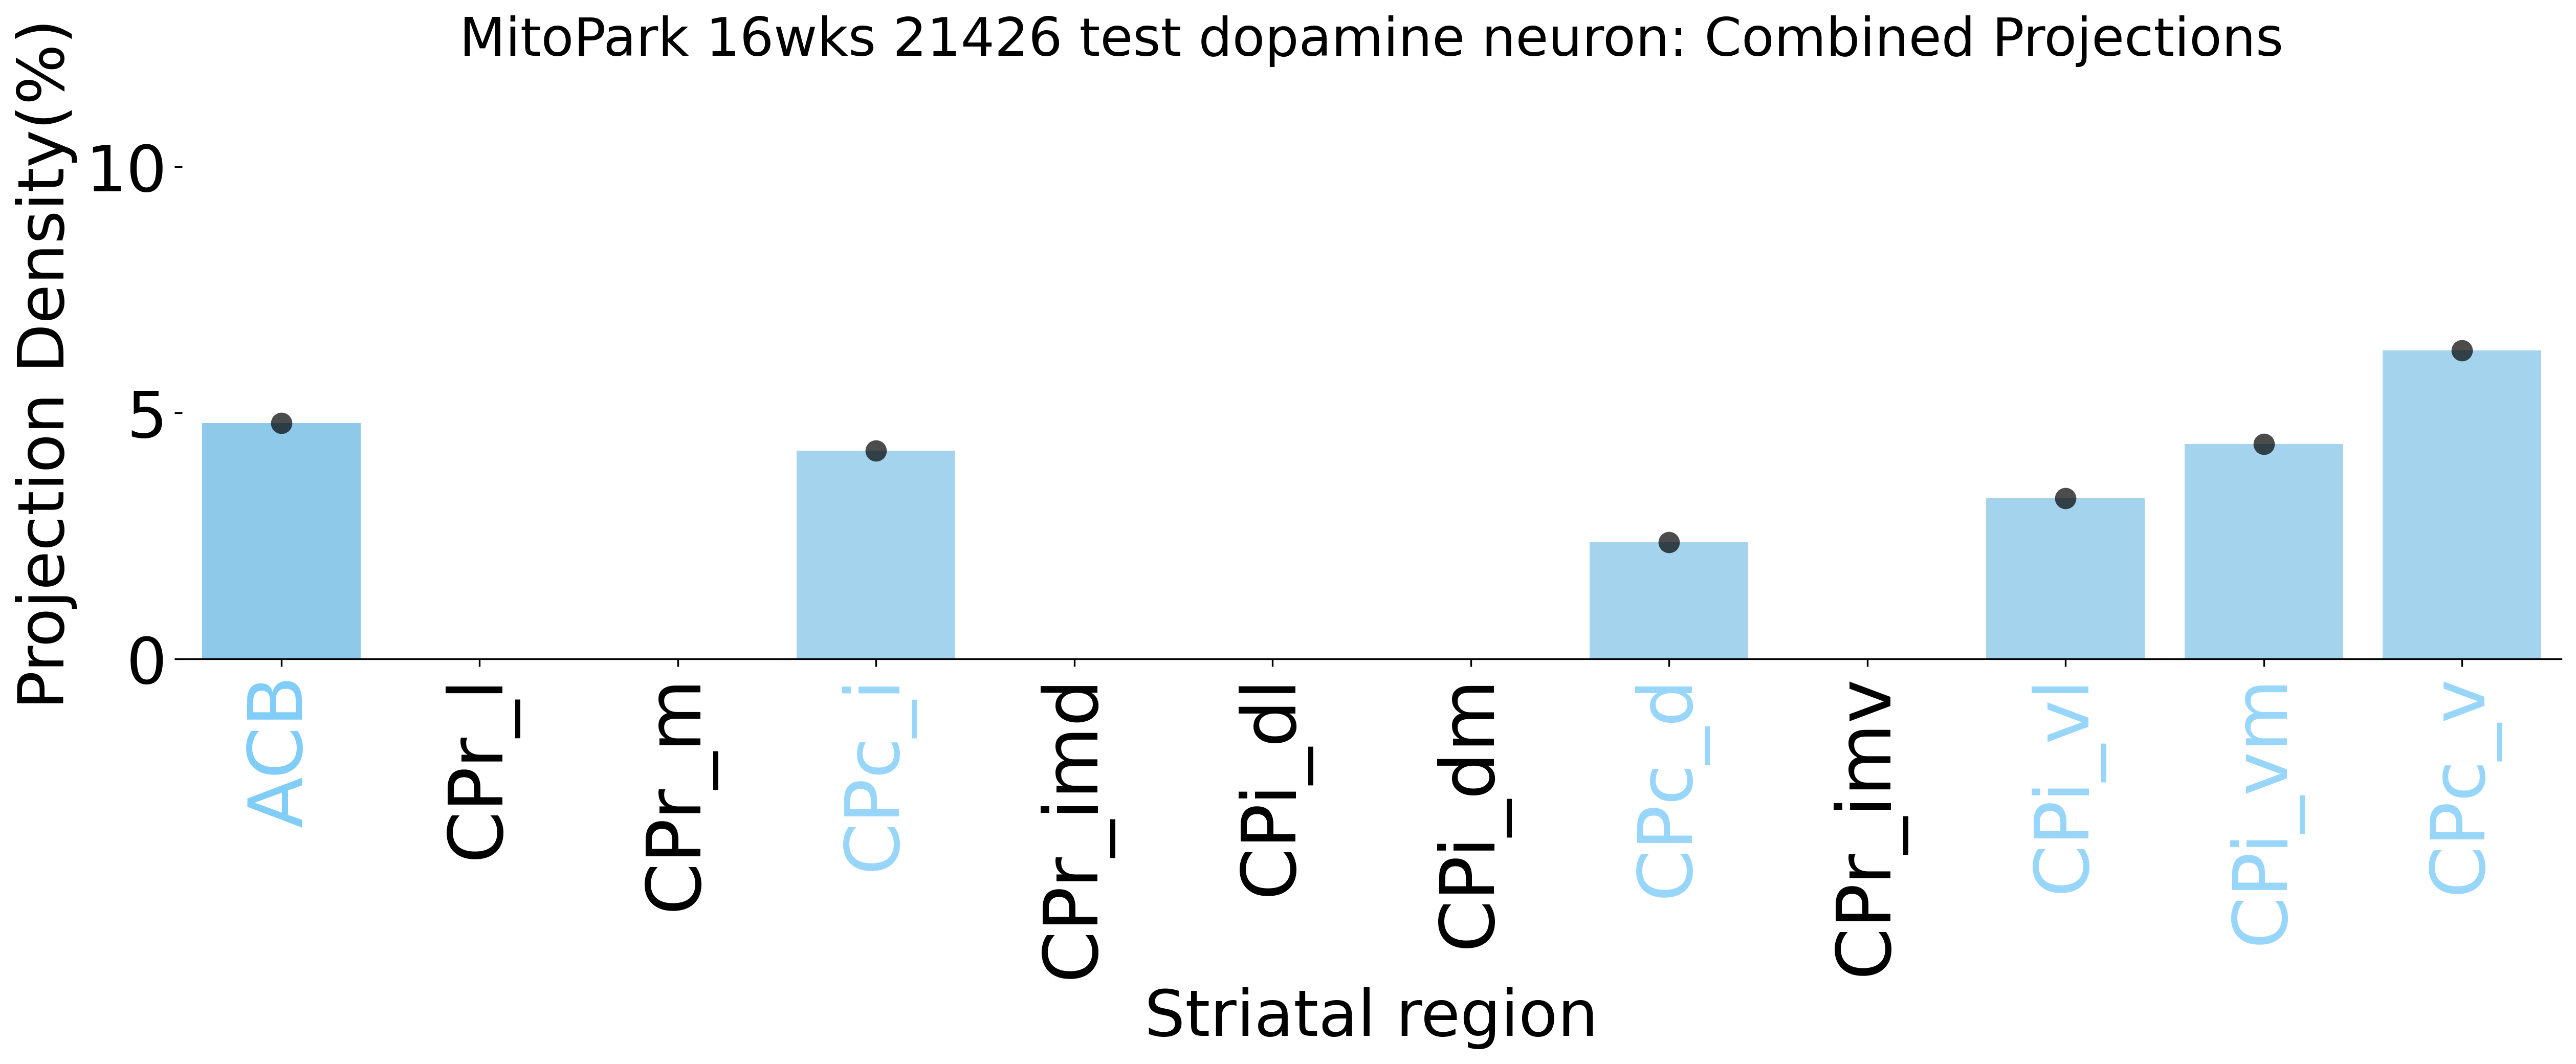

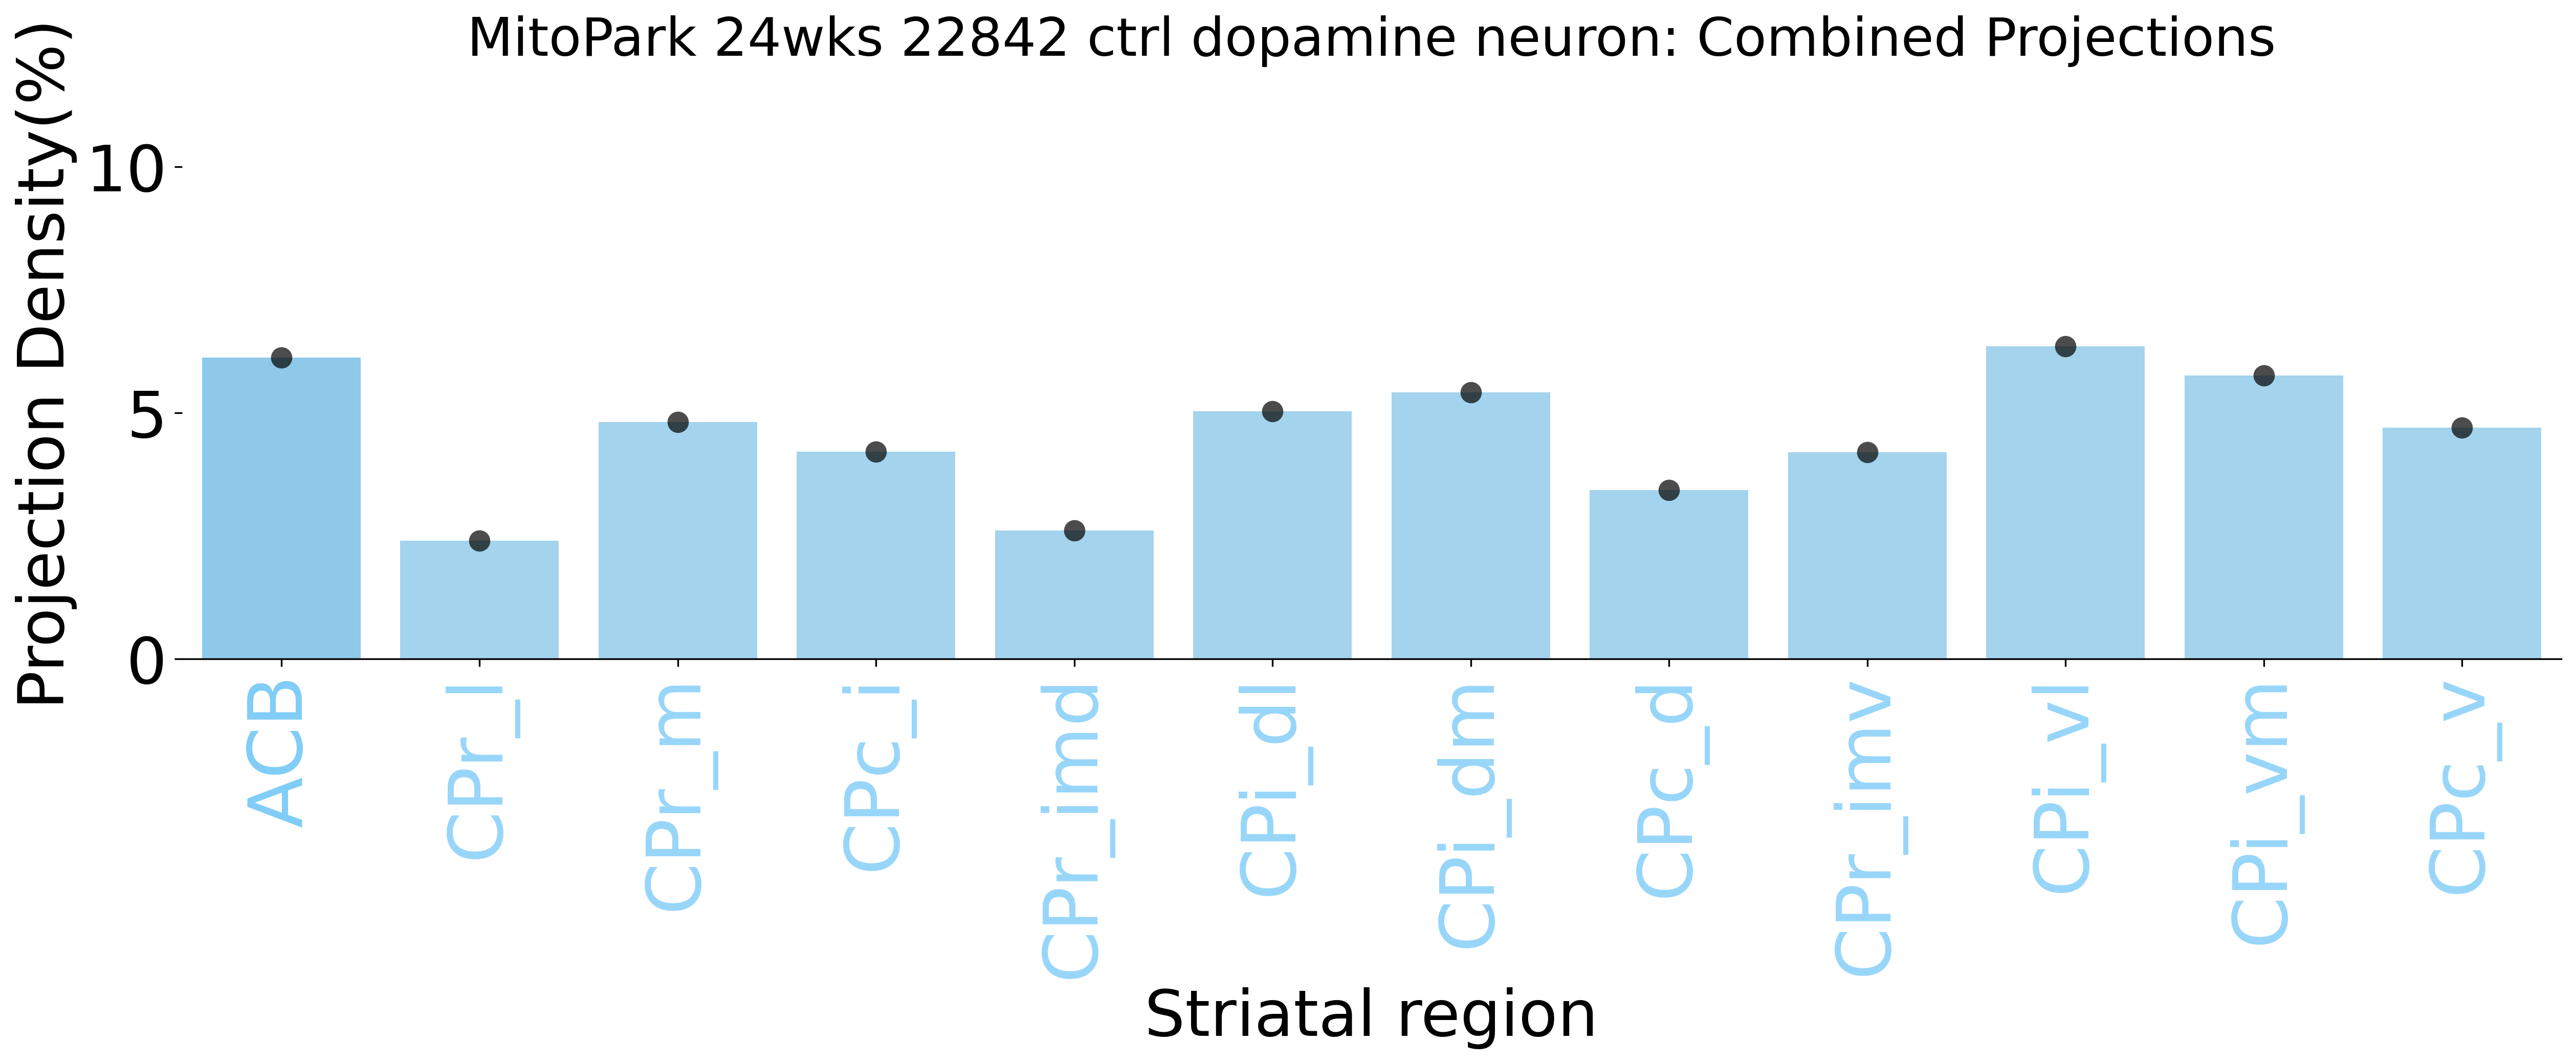

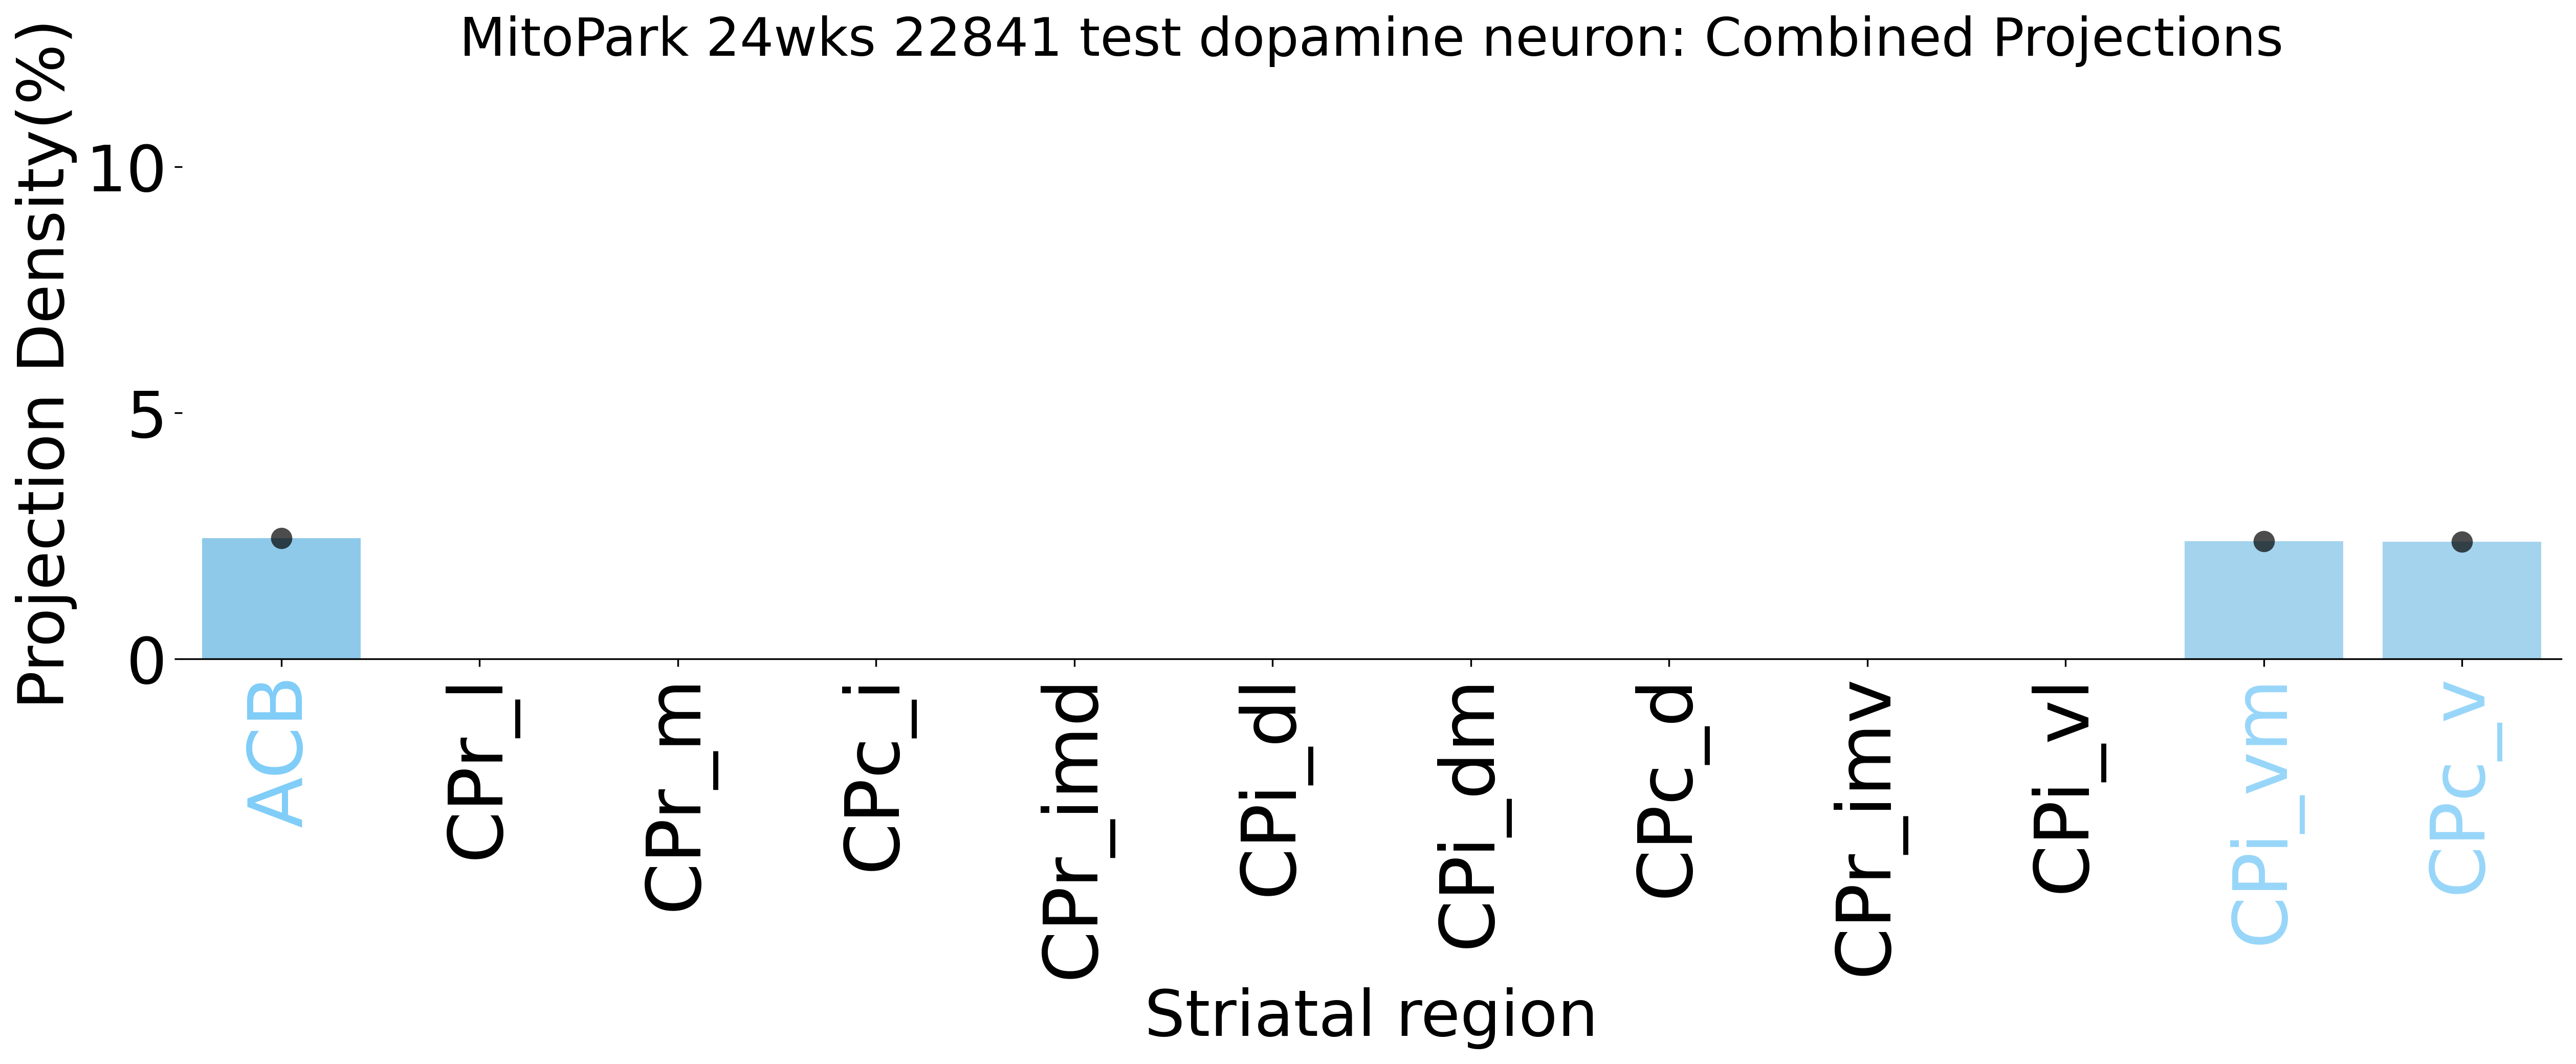

In [3]:
graph_map = {
    1304: 1400, 1307: 1401, 1313: 1402, 1305: 1403, 1308: 1404,
    1310: 1405, 1312: 1406, 1306: 1407, 1309: 1408, 1311: 1409, 1314: 1410,
}

Atlas_Regions['graph_order_changed'] = Atlas_Regions['graph_order'].replace(graph_map)
Atlas_Regions = Atlas_Regions.sort_values('graph_order_changed')

DAT_acronym = Atlas_Regions[['acronym']]

col_df = Atlas_Regions.assign(
    hex_color=Atlas_Regions[['red', 'green', 'blue']].apply(lambda r: bj.rgb_to_hex(*r), axis=1),
    graph_order_changed=lambda df: df['graph_order'].replace(graph_map),
)[['output_id', 'hex_color', 'acronym', 'name', 'graph_order', 'graph_order_changed']]

data_dir_full = os.path.join(data_dir, f'{dir_type}{atlas_type}', 'data')
suffix = f'{channel}Measured_{density}.csv'

for a in animals:
    filenames = [f for f in os.listdir(data_dir_full) if f.endswith(suffix) and a in f]

    df_DAT_both = bj.create_proj_df_for_figure_reorder_projections_both(
        data_dir, dir_type, atlas_type, filenames, ABA_fiber_tract, inj_site, col_df, proj_threshold
    )

    df_DAT_both_reorder = pd.merge(df_DAT_both, DAT_acronym, how='right', on='acronym')
    df_both, df_both_lf = bj.align_brain_region_projections_both(df_DAT_both_reorder)

    bj.create_figures_MP_projections_both(
        df_both, df_both_lf, average_method, ylim, save_dir, a, projection, atlas_type
    )